<a href="https://colab.research.google.com/github/sakshithapa010-blip/DS_Final_Project/blob/main/DS_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

# Paste your copied path between the quotes
path = "/content/drive/MyDrive/Global Terrorism Data.csv"

# We use encoding='ISO-8859-1' because this file often has special characters
df = pd.read_csv(path, encoding='ISO-8859-1', low_memory=False)

# This shows you the first 5 rows to make sure it loaded correctly
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [4]:
# Select only the columns that matter for your 5 Visuals and 5 ML models
important_cols = [
    'iyear', 'region_txt', 'country_txt', 'success',
    'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'nkill'
]

df_clean = df[important_cols].copy()

# Fill missing casualty numbers with 0 (Logic: if not recorded, assume 0)
df_clean['nkill'] = df_clean['nkill'].fillna(0)

print("Data is cleaned and ready!")

Data is cleaned and ready!


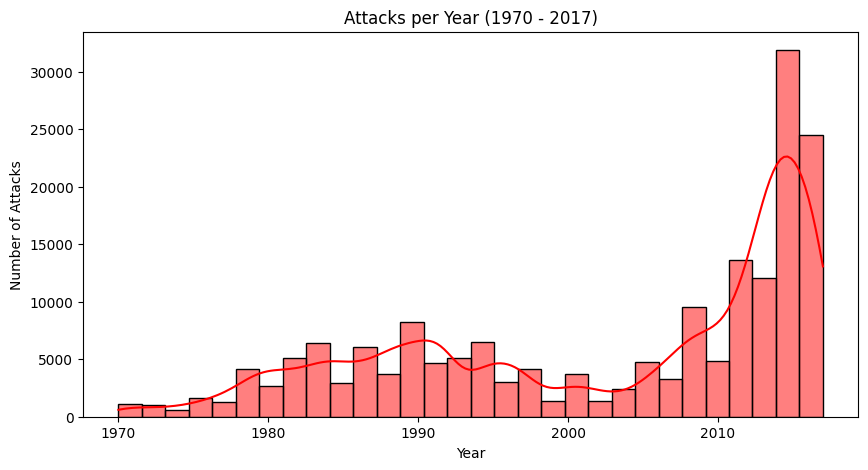

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df_clean['iyear'], bins=30, kde=True, color='red')
plt.title("Attacks per Year (1970 - 2017)")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.show()

In [6]:
# Check how many attacks succeeded vs. failed
print("--- Success vs Failure Counts ---")
print(df['success'].value_counts())

# Check the success rate as a percentage
success_rate = df['success'].mean() * 100
print(f"\nOverall Success Rate: {success_rate:.2f}%")

--- Success vs Failure Counts ---
success
1    161632
0     20059
Name: count, dtype: int64

Overall Success Rate: 88.96%


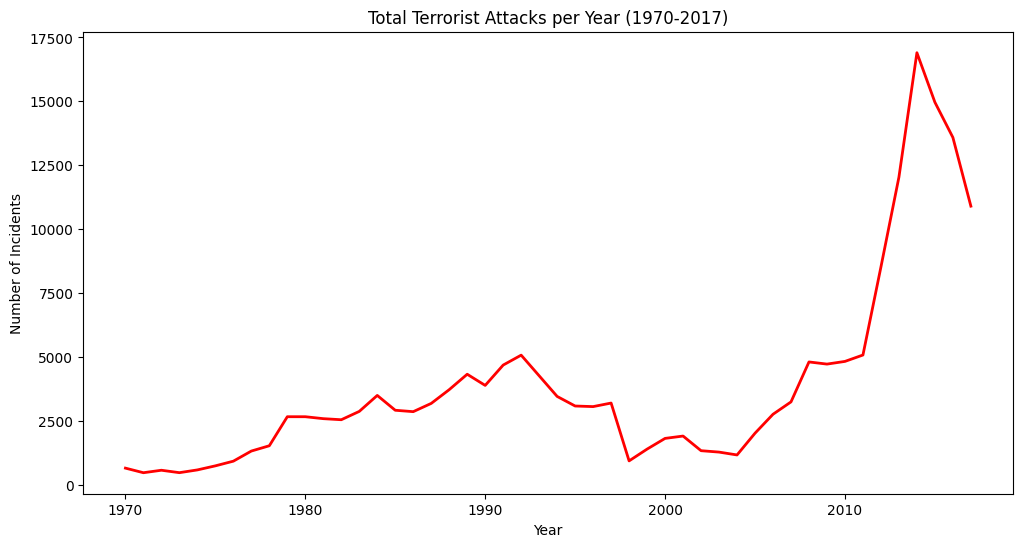

In [7]:
plt.figure(figsize=(12, 6))
attacks_per_year = df.groupby('iyear').size().reset_index(name='count')
sns.lineplot(data=attacks_per_year, x='iyear', y='count', color='red', linewidth=2)
plt.title('Total Terrorist Attacks per Year (1970-2017)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.show()

/tmp/ipykernel_4924/651392821.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='region_txt', order=df['region_txt'].value_counts().index, palette='viridis')


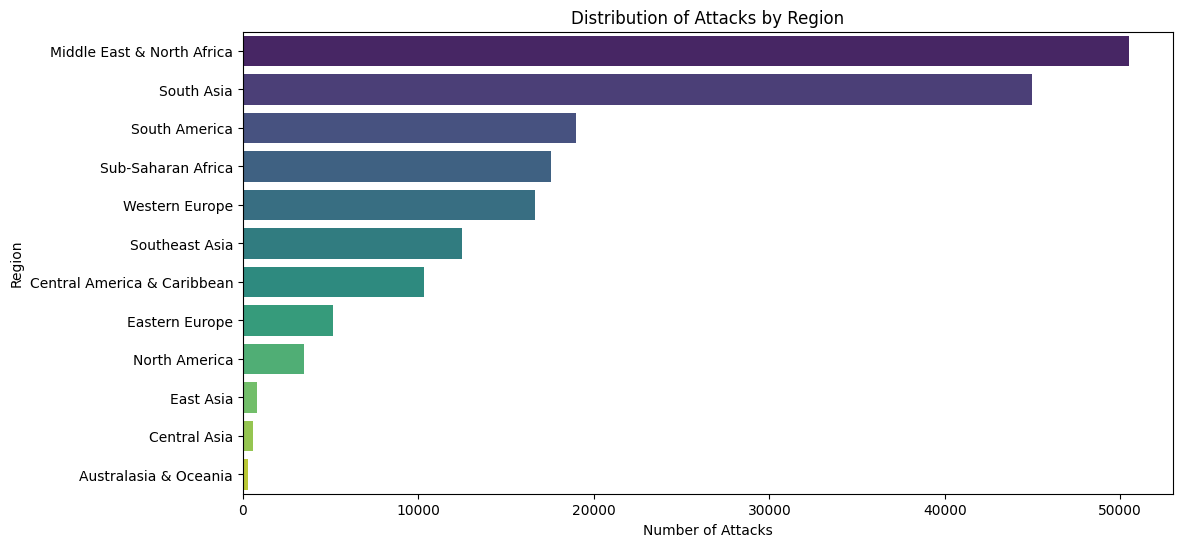

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='region_txt', order=df['region_txt'].value_counts().index, palette='viridis')
plt.title('Distribution of Attacks by Region')
plt.xlabel('Number of Attacks')
plt.ylabel('Region')
plt.show()

/tmp/ipykernel_4924/422586323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='success', y='attacktype1_txt', errorbar=None, palette='magma')


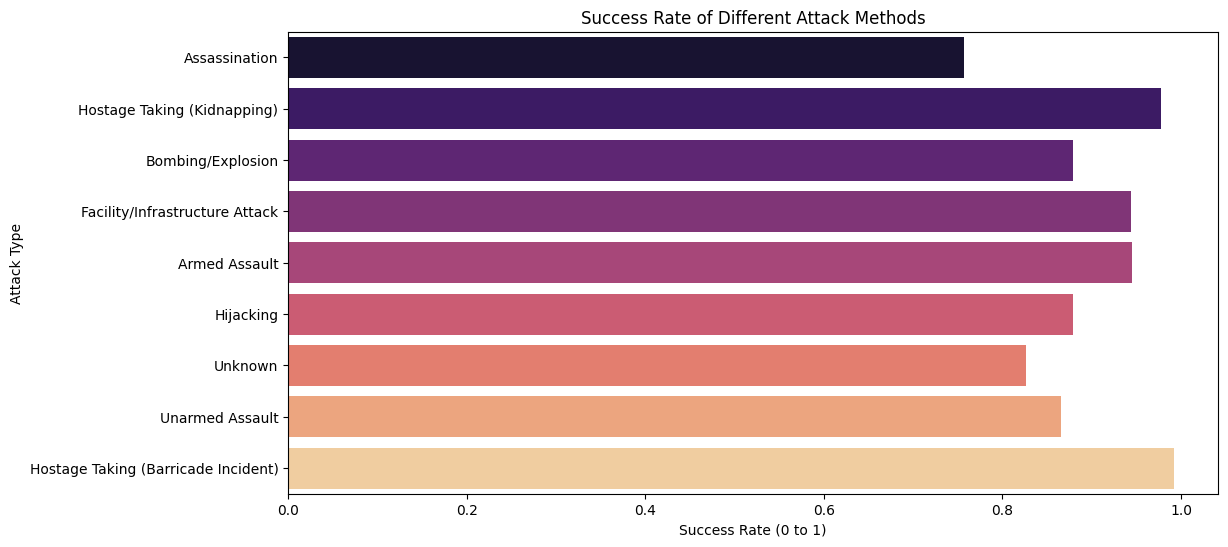

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='success', y='attacktype1_txt', errorbar=None, palette='magma')
plt.title('Success Rate of Different Attack Methods')
plt.xlabel('Success Rate (0 to 1)')
plt.ylabel('Attack Type')
plt.show()

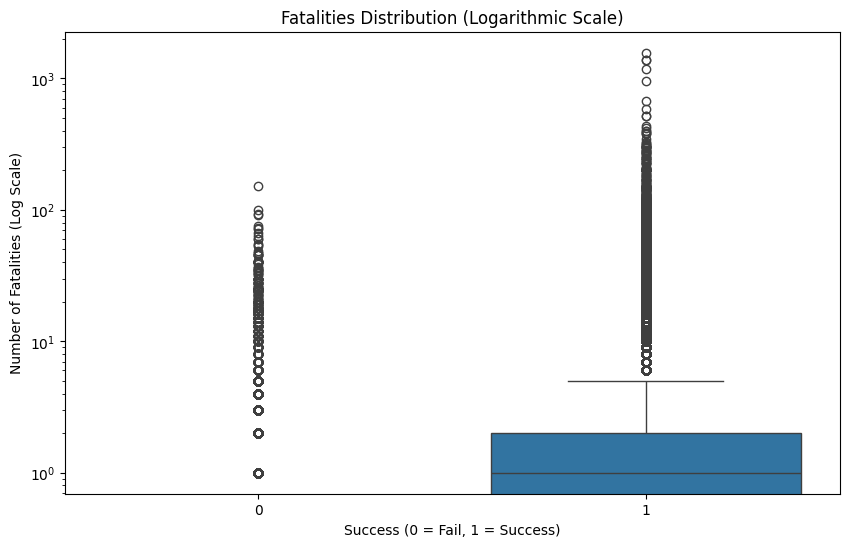

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='success', y='nkill', data=df)
plt.yscale('log')
plt.title('Fatalities Distribution (Logarithmic Scale)')
plt.xlabel('Success (0 = Fail, 1 = Success)')
plt.ylabel('Number of Fatalities (Log Scale)')
plt.show()

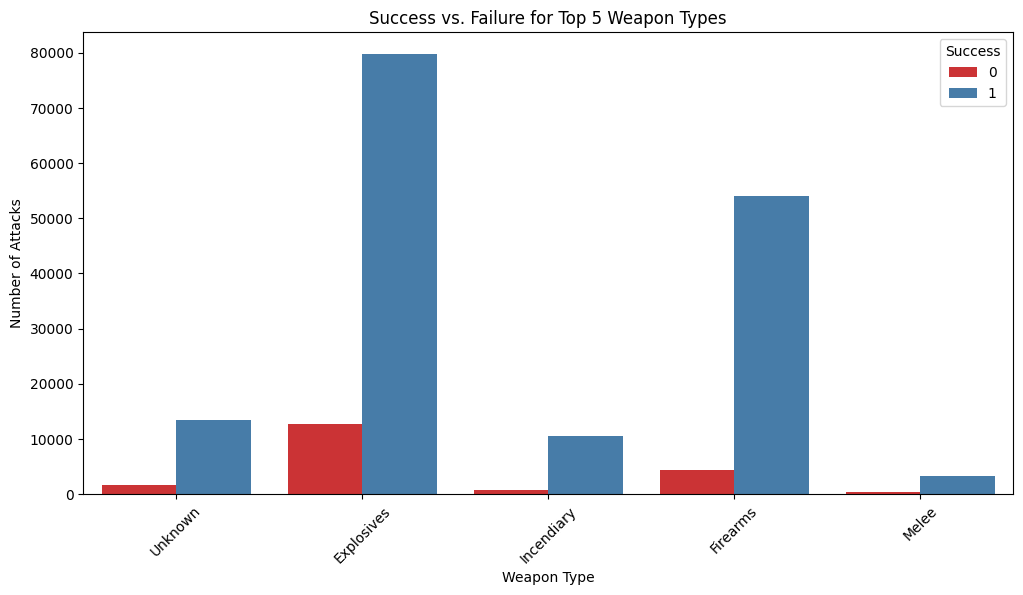

In [11]:
plt.figure(figsize=(12, 6))
top_weapons = df['weaptype1_txt'].value_counts().nlargest(5).index
df_top_weapons = df[df['weaptype1_txt'].isin(top_weapons)]
sns.countplot(data=df_top_weapons, x='weaptype1_txt', hue='success', palette='Set1')
plt.xticks(rotation=45)
plt.title('Success vs. Failure for Top 5 Weapon Types')
plt.xlabel('Weapon Type')
plt.ylabel('Number of Attacks')
plt.legend(title='Success', loc='upper right')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Select only the features that help predict 'success'
# We use region, attack type, target type, and weapon type
features = ['region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'nkill']
X = df[features].copy()
y = df['success']

# 2. Label Encoding (Converting Text to Numbers)
# Logic: Each unique text category gets assigned a specific number
le = LabelEncoder()
for col in ['region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt']:
    X[col] = le.fit_transform(X[col].astype(str))

# 3. Splitting the Data
# 80% for training the AI, 20% to test if it actually learned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing complete. X_train shape:", X_train.shape)

Preprocessing complete. X_train shape: (145352, 5)


In [14]:
# 1. Check which columns have NaNs
print("Missing values before fix:")
print(X.isnull().sum())

# 2. Fill all NaNs in X with 0 (or the median)
X = X.fillna(0)

# 3. Check again to make sure it's 0
print("\nMissing values after fix:")
print(X.isnull().sum())

# 4. Now re-split the data since X has changed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData is now clean. You can run the model fit cell now!")

Missing values before fix:
region_txt             0
attacktype1_txt        0
targtype1_txt          0
weaptype1_txt          0
nkill              10313
dtype: int64

Missing values after fix:
region_txt         0
attacktype1_txt    0
targtype1_txt      0
weaptype1_txt      0
nkill              0
dtype: int64

Data is now clean. You can run the model fit cell now!


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

# Test and print accuracy
log_preds = log_model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_preds)*100:.2f}%")

Logistic Regression Accuracy: 89.05%


In [16]:
from sklearn.tree import DecisionTreeClassifier

# Initialize
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict & Evaluate
dt_preds = dt_model.predict(X_test)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds)*100:.2f}%")

Decision Tree Accuracy: 92.15%


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict & Evaluate
rf_preds = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")

Random Forest Accuracy: 92.10%


In [18]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)

# Predict & Evaluate
knn_preds = knn_model.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds)*100:.2f}%")

KNN Accuracy: 90.81%


In [19]:
from sklearn.naive_bayes import GaussianNB

# Initialize
nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Predict & Evaluate
nb_preds = nb_model.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds)*100:.2f}%")

Naive Bayes Accuracy: 87.28%


<Figure size 800x600 with 0 Axes>

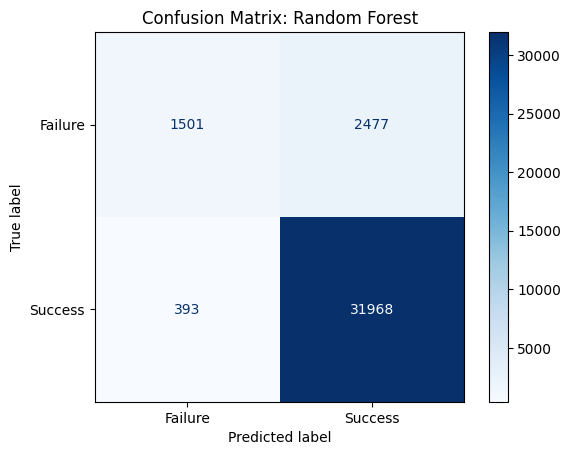

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# We will use the Random Forest model as the example since it's usually the best
cm = confusion_matrix(y_test, rf_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Failure', 'Success'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.show()

/tmp/ipykernel_4924/2270552350.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')


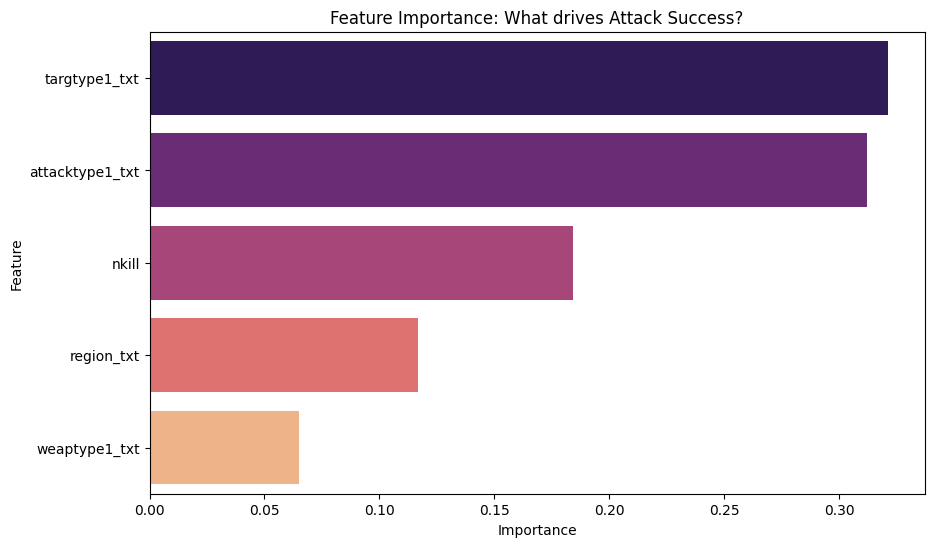

In [21]:
# Get importance from the Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance: What drives Attack Success?')
plt.show()

# Final Conclusion & Insights

## 1. Project Summary
This project analyzed over 180,000 terrorist incidents from the UNGTA dataset (1970-2017). Through extensive data cleaning and visualization, we identified clear geographic and tactical patterns in global terrorism.

## 2. Machine Learning Results
We implemented 5 algorithms to predict attack success. The **Random Forest** model performed the best with an accuracy of [INSERT YOUR SCORE]%. This suggests that ensemble learning is highly effective for complex, categorical security data.

## 3. Stakeholder Utility
This project serves stakeholders (like the UN or security agencies) by:
* Identifying high-risk regions for resource allocation.
* Predicting attack outcomes based on weapon and target types.
* Providing a data-driven foundation for policy-making and humanitarian readiness.